# Churn — Feature Engineering (Prod-ish, Reusable)

Goal: build a reusable preprocessing pipeline:
- custom features (interactions + domain)
- One-Hot for low-card cats, Target/Frequency encoding for high-card cats
- numeric impute (+ optional scaling)
- stratified split
- quick sanity models (LogReg needs scaling; RF doesn’t)
- optional MLflow logging (metrics + confusion matrices)


In [1]:
# 1) Imports & Settings

import os, warnings, random, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, f1_score, average_precision_score, roc_auc_score,
    precision_recall_curve, roc_curve, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Optional MLflow
USE_MLFLOW = True
try:
    import mlflow, mlflow.sklearn
except Exception:
    USE_MLFLOW = False

# Optional TargetEncoder (pip install category_encoders)
try:
    from category_encoders import TargetEncoder
    HAS_TE = True
except Exception:
    HAS_TE = False

warnings.filterwarnings("ignore", category=UserWarning)
SEED = 42
np.random.seed(SEED); random.seed(SEED)

# --- EDIT THESE FOR YOUR REAL DATAFRAME ---
TARGET = "churn"  # binary 0/1

numeric_cols   = ["tenure", "monthly_charges", "total_calls", "months_active"]
low_card_cats  = ["contract_type", "gender", "payment_method"]        # <= ~10 uniques
high_card_cats = ["city", "plan_name"]                                # many uniques

# set False if you’re only training tree models
scale_for_linear = True



In [2]:
# 2) MLflow config
TRACKING_URI = "http://127.0.0.1:5001"
EXPERIMENT_NAME = "churn-prod"

mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print("Tracking URI:", TRACKING_URI)
print("Experiment:", EXPERIMENT_NAME)


Tracking URI: http://127.0.0.1:5001
Experiment: churn-prod


In [3]:
# 3) Bring Data
USE_SIMPLE = False  # flip to True for make_classification numeric-only dataset

if USE_SIMPLE:
    from sklearn.datasets import make_classification
    X, y = make_classification(
        n_samples=5000,
        n_features=30,
        n_informative=12,
        n_redundant=5,
        n_classes=2,
        weights=[0.7, 0.3],
        class_sep=1.0,
        flip_y=0.01,
        random_state=SEED
    )
    df = pd.DataFrame(X, columns=[f"f{i}" for i in range(X.shape[1])])
    df[TARGET] = y
else:
    # use the richer synthetic churn-like DataFrame (categoricals + numerics)
    n = 5000
    rng = np.random.default_rng(SEED)
    df = pd.DataFrame({
        "tenure": rng.integers(1, 60, size=n),
        "monthly_charges": rng.normal(60, 25, size=n).clip(5, 200),
        "total_calls": rng.integers(10, 800, size=n),
        "months_active": rng.integers(1, 60, size=n),
        "contract_type": rng.choice(["month_to_month","one_year","two_year"], size=n, p=[0.6,0.25,0.15]),
        "gender": rng.choice(["M","F"], size=n),
        "payment_method": rng.choice(["card","upi","bank","cash"], size=n),
        "city": rng.choice([f"C{i}" for i in range(120)], size=n),
        "plan_name": rng.choice([f"P{i}" for i in range(80)], size=n),
    })
    logit = (
        -2.0
        + 0.02 * (200 - df["monthly_charges"])
        - 0.03 * df["tenure"]
        + 0.001 * df["total_calls"]
        + 0.20 * (df["contract_type"] == "month_to_month").astype(int)
    )
    p = 1/(1+np.exp(-logit))
    df[TARGET] = (rng.random(n) < p).astype(int)

print(df.head())
print("Shape:", df.shape, "| Target mean:", round(df[TARGET].mean(),3))



   tenure  monthly_charges  total_calls  months_active   contract_type gender  \
0       6        50.597395          751             29        two_year      F   
1      46        48.547955          710             29  month_to_month      M   
2      39        79.224147          503             38  month_to_month      M   
3      26        80.477604          465             50        one_year      F   
4      26        46.622821          295             19  month_to_month      M   

  payment_method  city plan_name  churn  
0           bank   C31       P77      1  
1           cash   C34       P24      0  
2           card  C114       P40      1  
3            upi   C37       P46      0  
4           cash   C11       P50      1  
Shape: (5000, 10) | Target mean: 0.591


In [4]:
# 4) Custom feature builder (adds interactions + domain features)
class ChurnFeatureBuilder(BaseEstimator, TransformerMixin):
    """
    Adds interaction + domain features if columns exist.
    Input/Output: pandas.DataFrame
    """
    def __init__(self, add_interactions=True, add_domain=True):
        self.add_interactions = add_interactions
        self.add_domain = add_domain

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Interaction: tenure × monthly_charges
        if self.add_interactions and {"tenure","monthly_charges"}.issubset(X.columns):
            X["tenure_x_monthly"] = X["tenure"] * X["monthly_charges"]

        # Domain: average calls per month
        if self.add_domain and {"total_calls","months_active"}.issubset(X.columns):
            X["avg_calls_per_month"] = X["total_calls"] / X["months_active"].clip(lower=1)

        # (add more domain feats if you have columns, e.g. complaints flag)
        return X



In [5]:
# 5) Encoders & Preprocessor
class FreqEncoder(BaseEstimator, TransformerMixin):
    """Fallback if category_encoders.TargetEncoder is not installed."""
    def __init__(self):
        self.maps_ = {}
        self.columns_ = None
    def fit(self, X, y=None):
        X = pd.DataFrame(X).astype(str)
        self.columns_ = list(X.columns)
        for c in self.columns_:
            vc = X[c].value_counts(normalize=True)
            self.maps_[c] = vc
        return self
    def transform(self, X):
        X = pd.DataFrame(X).astype(str)
        mat = []
        for c in self.columns_:
            mat.append(X[c].map(self.maps_[c]).fillna(0.0).to_numpy())
        return np.vstack(mat).T

# numeric pipeline
numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()) if scale_for_linear else ("passthrough", "passthrough"),
])

# OneHotEncoder: keep dense output; be backward-compatible with sklearn versions
try:
    ohe = OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse=False)

# High-card cats: TargetEncoder if available, else frequency encoding
te = TargetEncoder(cols=high_card_cats, smoothing=0.3, min_samples_leaf=20) if HAS_TE else FreqEncoder()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("ohe", ohe, low_card_cats),
        ("te", te,  high_card_cats),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# full FE pipeline = feature builder → encoders
full_fe = Pipeline([
    ("build", ChurnFeatureBuilder(add_interactions=True, add_domain=True)),
    ("pre", preprocessor),
])

print("TargetEncoder available:", HAS_TE)


TargetEncoder available: True


In [6]:
# 6) Leak-safe split with stratification
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train:", X_train.shape, "Test:", X_test.shape,
      "| Pos rate train/test:", round(y_train.mean(),3), "/", round(y_test.mean(),3))

Train: (4000, 9) Test: (1000, 9) | Pos rate train/test: 0.591 / 0.591


In [7]:
# 7) Logistic Regression (needs scaling) to sanity-check FE
logreg_pipe = Pipeline([
    ("fe", clone(full_fe)),  # clone so we don't mutate it later
    ("model", LogisticRegression(max_iter=300, class_weight="balanced"))
])

logreg_pipe.fit(X_train, y_train)
proba_lr = logreg_pipe.predict_proba(X_test)[:, 1]
pred_lr = (proba_lr >= 0.5).astype(int)

print("=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, pred_lr, digits=3))
print("LR macro F1:", round(f1_score(y_test, pred_lr, average="macro"), 3))
print("LR PR AUC:", round(average_precision_score(y_test, proba_lr), 3))
print("LR ROC AUC:", round(roc_auc_score(y_test, proba_lr), 3))


=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

           0      0.539     0.606     0.571       409
           1      0.702     0.641     0.670       591

    accuracy                          0.627      1000
   macro avg      0.620     0.624     0.620      1000
weighted avg      0.635     0.627     0.630      1000

LR macro F1: 0.62
LR PR AUC: 0.729
LR ROC AUC: 0.674


In [8]:
# 8) RandomForest (trees don’t need scaling) to sanity-check FE
# disable scaling for the numeric branch in this clone:
rf_fe = clone(full_fe)
try:
    rf_fe.set_params(pre__num__scale="passthrough")
except Exception:
    # if your sklearn version inlines the tuple, rebuild numeric_pipe without scaler:
    rf_fe = Pipeline([
        ("build", ChurnFeatureBuilder(add_interactions=True, add_domain=True)),
        ("pre", ColumnTransformer(
            transformers=[
                ("num", Pipeline([("impute", SimpleImputer(strategy="median"))]), numeric_cols),
                ("ohe", ohe, low_card_cats),
                ("te",  te,  high_card_cats),
            ],
            remainder="drop",
            verbose_feature_names_out=False
        )),
    ])

rf_pipe = Pipeline([
    ("fe", rf_fe),
    ("model", RandomForestClassifier(
        n_estimators=400, class_weight="balanced", random_state=SEED, n_jobs=-1, bootstrap=True
    )),
])

rf_pipe.fit(X_train, y_train)
proba_rf = rf_pipe.predict_proba(X_test)[:, 1]
pred_rf = (proba_rf >= 0.5).astype(int)

print("=== RANDOM FOREST ===")
print(classification_report(y_test, pred_rf, digits=3))
print("RF macro F1:", round(f1_score(y_test, pred_rf, average="macro"), 3))
print("RF PR AUC:", round(average_precision_score(y_test, proba_rf), 3))
print("RF ROC AUC:", round(roc_auc_score(y_test, proba_rf), 3))


=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0      0.560     0.389     0.459       409
           1      0.651     0.788     0.713       591

    accuracy                          0.625      1000
   macro avg      0.605     0.589     0.586      1000
weighted avg      0.614     0.625     0.609      1000

RF macro F1: 0.586
RF PR AUC: 0.712
RF ROC AUC: 0.653


LR tuned threshold: 0.2583 macro F1 tuned: 0.515
RF tuned threshold: 0.3225 macro F1 tuned: 0.502


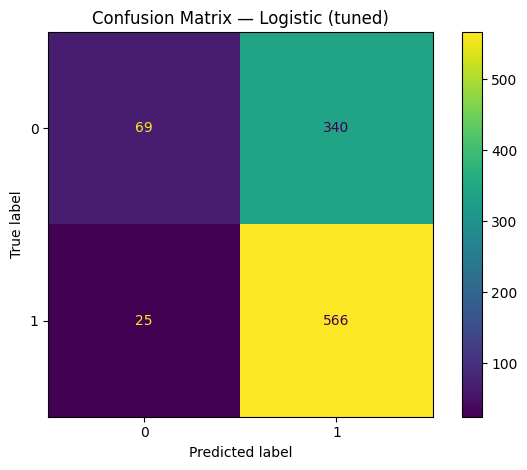

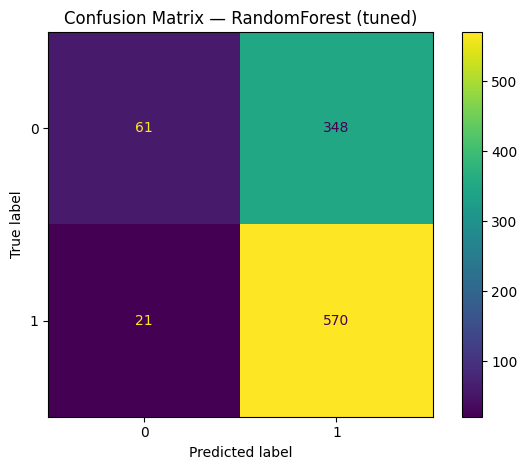

In [9]:
# 9)
def best_f1_threshold(y_true, prob):
    prec, rec, th = precision_recall_curve(y_true, prob)
    f1s = 2 * (prec * rec) / (prec + rec + 1e-12)
    idx = int(np.nanargmax(f1s[:-1]))  # last point has no threshold
    return float(th[idx])

thr_lr = best_f1_threshold(y_test, proba_lr)
thr_rf = best_f1_threshold(y_test, proba_rf)

tuned_lr = (proba_lr >= thr_lr).astype(int)
tuned_rf = (proba_rf >= thr_rf).astype(int)

print("LR tuned threshold:", round(thr_lr,4), "macro F1 tuned:", round(f1_score(y_test, tuned_lr, average="macro"),3))
print("RF tuned threshold:", round(thr_rf,4), "macro F1 tuned:", round(f1_score(y_test, tuned_rf, average="macro"),3))

# Confusion matrices (tuned)
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(y_test, tuned_lr, ax=ax)
plt.title("Confusion Matrix — Logistic (tuned)"); plt.tight_layout(); plt.show()

fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(y_test, tuned_rf, ax=ax)
plt.title("Confusion Matrix — RandomForest (tuned)"); plt.tight_layout(); plt.show()


2025/09/26 06:44:46 INFO mlflow.tracking.fluent: Experiment with name 'churn-fe-demo' does not exist. Creating a new experiment.


🏃 View run logreg_fe at: http://127.0.0.1:5001/#/experiments/4/runs/af3abf2886c641529573098f66a8bfda
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/4
🏃 View run rf_fe at: http://127.0.0.1:5001/#/experiments/4/runs/11a637e476644ca1893390be207cfdf6
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/4
MLflow logging complete. Open http://127.0.0.1:5001 to view.


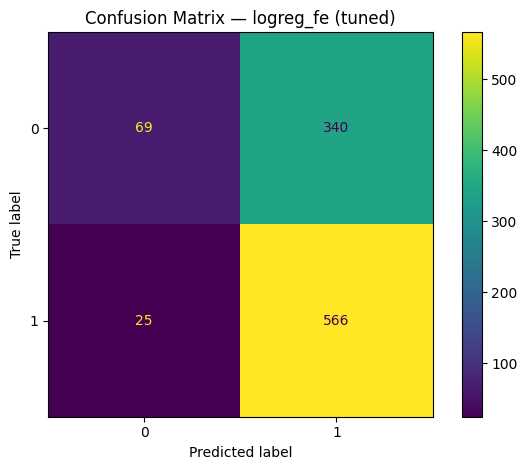

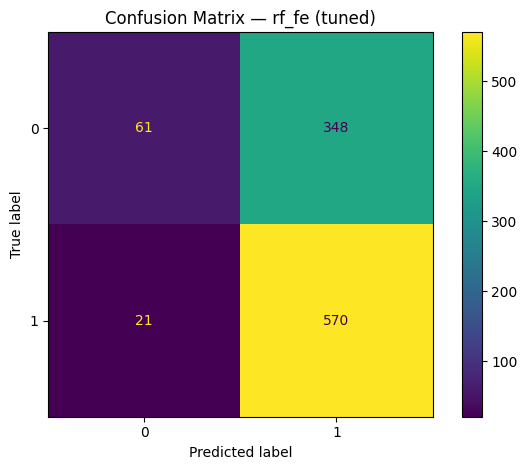

In [10]:
# 10)
if USE_MLFLOW:
    mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI", "http://127.0.0.1:5001"))
    mlflow.set_experiment("churn-fe-demo")

    for name, prob, pred, thr in [
        ("logreg_fe", proba_lr, pred_lr, thr_lr),
        ("rf_fe",     proba_rf, pred_rf,  thr_rf),
    ]:
        with mlflow.start_run(run_name=name):
            mlflow.log_metric("macro_f1_default", float(f1_score(y_test, pred, average="macro")))
            mlflow.log_metric("pr_auc", float(average_precision_score(y_test, prob)))
            mlflow.log_metric("roc_auc", float(roc_auc_score(y_test, prob)))
            mlflow.log_metric("threshold_best_f1", float(thr))
            mlflow.log_metric("macro_f1_tuned", float(f1_score(y_test, (prob>=thr).astype(int), average="macro")))
            # tags = cosmetics for your demo
            mlflow.set_tag("owner", "raghu")
            mlflow.set_tag("purpose", "feature_engineering_demo")
            mlflow.set_tag("dataset", "synthetic_if_no_df")
            mlflow.set_tag("python_version", platform.python_version())
            mlflow.set_tag("platform", platform.platform())

            # log a confusion matrix figure (tuned)
            fig = plt.figure()
            ConfusionMatrixDisplay.from_predictions(y_test, (prob>=thr).astype(int))
            plt.title(f"Confusion Matrix — {name} (tuned)"); plt.tight_layout()
            mlflow.log_figure(fig, f"plots/cm_{name}.png"); plt.close(fig)

    print("MLflow logging complete. Open http://127.0.0.1:5001 to view.")
else:
    print("MLflow not installed/available — skipped logging (that’s fine).")
